# Homework 1: Part 2

## Name: Terry Cevallos

## 2. Trophic Chain Dynamics (10 points)

The system of ordinary differential equations (ODEs) describing a three-level food chain consisting of a primary resource ($x$), a herbivore ($y$), and a top predator ($z$) is given by:

$$
\begin{aligned}
\frac{dx}{dt} &= r\,x \left( 1 - \frac{x}{K} \right) - \frac{a_1\,x\,y}{1 + b_1\,x} \\
\frac{dy}{dt} &= \frac{e_1\,a_1\,x\,y}{1 + b_1\,x} - \frac{a_2\,y\,z}{1 + b_2\,y} - d_1\,y \\
\frac{dz}{dt} &= \frac{e_2\,a_2\,y\,z}{1 + b_2\,y} - d_2\,z
\end{aligned}
$$

Where:

- $r$: Intrinsic growth rate of the resource.
- $K$: Carrying capacity of the resource.
- $a_1, a_2$: Capture rates (searching efficiency) for herbivores and predators.
- $b_1, b_2$: Saturation parameters related to consumer handling time.
- $e_1, e_2$: Assimilation efficiencies (energy conversion).
- $d_1, d_2$: Natural death rates of the herbivore and predator.

This system uses a **Type II functional response**, which accounts for predator saturation due to handling time.



### State vector and slope

**(a)** Write the system of ODEs in terms of the system state vector $S(t)$ so that the system can be written as $\frac{dS}{dt} = F(t,S)$. Identify the slope function $F(t,S)$ and indicate whether it depends explicitly on time.

Define my state vector

$$S(t) = \begin{pmatrix} 
x(t) \\ 
y(t) \\ 
z(t) 
\end{pmatrix}$$

and also define slope function as follows.

$$\frac{dS}{dt} = F(t, S) = \begin{bmatrix} 
r \, x \left( 1 - \frac{x}{K} \right) - \frac{a_1 x y}{1 + b_1 x} \\ 
\frac{e_1 a_1 x y}{1 + b_1 x} - \frac{a_2 y z}{1 + b_2 y} - d_1 y \\ 
\frac{e_2 a_2 y z}{1 + b_2 y} - d_2 z 
\end{bmatrix}$$



From the equations, we can see that it does not explicitly depend on time, since the time variable (t) does not appear in the equations, which means that population change occurs only due to the interaction between species. 

### Class implementation

**(b)** Implement the model using a **single Python class**.

The class should contain:

- the system parameters
- the initial conditions
- the time span
- the time step size
- the selected integration method

Inside the class, implement a method that evaluates the slope function $F(t,S)$.

```Python
class ChainDinamics:
    def __init__(self, parameters, init_c, t_span, step_size, method):
        
        """
        This class was created to solve the ODE of the 
        trophic chain population dynamics using the RK3 and BRK methods.
        Inputs:
            - parameters: a dictionary with the parameters.
            - init_c: list with the initial conditions. [x,y,z][float]
            - t_span: a tuple with the initial and final time. (t_0, t_f) [float]
            - step_size: step size of the integration. [float]
            - method: a list with the method to integrate the ODE. ["RK3", "BRK"][string]
        Outputs:
            - t: a numpy array with the time vector 
            - S: a numpy array with the state vector
            - figure: a plot with the population dynamics of the trophic chain
        Author: TPCR
        Date: 11-03-2026
        """        
        # Define the parameters
        self.parameters = parameters
        self.S0 = np.array(init_c)
        self.t_0 = t_span[0]
        self.t_f = t_span[1]
        self.step_size = step_size
        self.method = method
    def slope(self, t, S):
        """
        This function defines the slope of the ODE system.
        Inputs:
            - t: time [float]
            - S: state vector [numpy array]
        Outputs:
            - dxdt, dydt, dzdt: derivatives of the state vector [numpy array]
        Author: TPCR
        Date: 11-03-2026
        """
        # State vector
        x ,y ,z = S
        # Define the constants
        r = self.parameters['r']
        k = self.parameters['k']
        a1 = self.parameters['a1']
        b1 = self.parameters['b1']
        e1 = self.parameters['e1']
        d1 = self.parameters['d1']
        a2 = self.parameters['a2']
        b2 = self.parameters['b2']
        e2 = self.parameters['e2']
        d2 = self.parameters['d2']
        # Define the functionals
        f1 = (a1 * x * y) / (1 + b1 * x)
        f2 = (a2 * y * z) / (1 + b2 * y)
        # Define the derivatives
        dxdt = r * x * (1 - x / k) - f1
        dydt = e1 * f1 - f2 - d1 * y
        dzdt = e2 * f2 - d2 * z

        return np.array([dxdt, dydt, dzdt])      
```

### ODE integration methods

**(c)** Implement a class method for the following **third-order Runge–Kutta method (RK3)**:

$$
\begin{aligned}
k_1 &= F(t_j, S_j) \\
k_2 &= F\left(t_j + \frac{h}{2}, S_j + \frac{h}{2}k_1 \right) \\
k_3 &= F\left(t_j + h, S_j - hk_1 + 2hk_2 \right)
\end{aligned}
$$

The update step is

$$
S_{j+1} = S_j + \frac{h}{6}\left(k_1 + 4k_2 + k_3\right).
$$

```Python
   def rk3_method(self, t, S):
        """
        This function defines the RK3 method to integrate the ODE system.
        Inputs:
            - t: time [float]
            - S: state vector [numpy array]
        Outputs:
            - S_next: next state vector [numpy array]   
        Author: TPCR
        Date: 11-03-2026
        """
        # Define the step size
        h = self.step_size
        # Define the slopes    
        k1 = self.slope(t, S)
        k2 = self.slope(t + h/2, S + (h/2) * k1)
        k3 = self.slope(t + h, S - h*k1 + 2*h*k2)
        S_next = S + (h / 6) * (k1 + 4 * k2 + k3)

        return S_next
```

**(d)** Implement a class method for **Butcher's Runge–Kutta method**, which uses six slope evaluations:

$$
\begin{aligned}
k_1 &= F(t_j, S_j) \\
k_2 &= F\left(t_j + \frac{h}{4}, S_j + \frac{1}{4}k_1 h\right) \\
k_3 &= F\left(t_j + \frac{h}{4}, S_j + \frac{1}{8}k_1 h + \frac{1}{8}k_2 h\right) \\
k_4 &= F\left(t_j + \frac{h}{2}, S_j - \frac{1}{2}k_2 h + k_3 h\right) \\
k_5 &= F\left(t_j + \frac{3h}{4}, S_j + \frac{3}{16}k_1 h + \frac{9}{16}k_4 h\right) \\
k_6 &= F\left(t_j + h, S_j - \frac{3}{7}k_1 h + \frac{2}{7}k_2 h + \frac{12}{7}k_3 h - \frac{12}{7}k_4 h + \frac{8}{7}k_5 h\right)
\end{aligned}
$$

The solution is then constructed with step size $h$ (`dt`) as

$$
S_{j+1} = S_j + \frac{h}{90}\left(7k_1 + 32k_3 + 12k_4 + 32k_5 + 7k_6\right).
$$

```Python
     def brk_method(self ,t ,S):
        """
        This function defines the BRK method to integrate the ODE system.
        Inputs:
            - t: time [float]
            - S: state vector [numpy array]
        Outputs:
            - S_next: next state vector [numpy array]
        Author: TPCR
        Date: 12-03-2026
        """
        # Define the step size
        h = self.step_size
        # Define the slopes    
        k1 = self.slope(t, S)
        k2 = self.slope(t + h/4, S + 1/4 * k1 * h)
        k3 = self.slope(t + h/4, S + 1/8 * k1 * h + 1/8 * k2 * h)
        k4 = self.slope(t + h/2, S - 1/2 * k2 * h + k3 * h)
        k5 = self.slope(t + 3 * h/4, S + 3/16 * k1 * h + 9/16 * k4 * h)
        k6 = self.slope(t + h, S - 3/7 * k1 * h + 2/7 * k2 * h + 12/7 * k3 * h - 12/7 * k4 * h + 8/7 * k5 * h)
        
        S_next = S + h / 90 * (7 * k1 + 32 * k3 + 12 * k4 + 32 * k5 + 7 * k6)

        return S_next
```

### Settings and initial conditions

**(e)** Create a dictionary that allocates all user-defined initial conditions needed for integration, including an option for the user to select the integration method.

The default parameters should be:

| Parameter | Value | Description |
|---|---|---|
| `r`, `K` | 1.2, 1.0 | Resource growth rate and carrying capacity |
| `a1`, `b1`, `e1`, `d1` | 5.0, 3.0, 0.5, 0.4 | Herbivore capture rate, saturation parameter, efficiency, death rate |
| `a2`, `b2`, `e2`, `d2` | 0.1, 2.0, 0.1, 0.01 | Predator capture rate, saturation parameter, efficiency, death rate |
| `x0`, `y0`, `z0` | 0.5, 0.2, 0.1 | Initial populations (resource, herbivore, predator) |
| `t_span`, `dt` | (0, 500), 0.05 | Simulation time span and time step |
| `method` | `"rk3"` | Integration method |

In [16]:
# Create a diccionary with the parameters
settings = {
            'parameters': {
                        'r': 0.5, 
                        'k': 1.0, 
                        'a1': 5.0, 
                        'b1': 3.0, 
                        'e1': 0.5, 
                        'd1': 0.4, 
                        'a2': 0.1, 
                        'b2': 2.0, 
                        'e2': 0.1, 
                        'd2': 0.01},
            'init_c': [0.5, 0.2, 0.1],
            't_span': (0, 500),
            'step_size': 0.05,
            'method': ["RK3", "BRK"]
        }


### Time stepping

**(f)** Implement a class method that integrates the system of ODEs using the settings and initial conditions stored in the class. The method should return the resulting times ($t$) and system states $S(t)$ as arrays.

```Python
def integrate_ODE(self):
        """
        This function integrates the ODE system using the selected method.
        Inputs: -
        Outputs:
            - t: a numpy array with the time vector 
            - S: a numpy array with the state vector
        Author: TPCR
        Date: 12-03-2026
        """
        # Define the step size
        h = self.step_size
        # Define the time vector 
        t0 = self.t_0
        tf = self.t_f
        t_vector = np.arange(t0, tf, h)        
        # Define the initial state             
        S_values = np.zeros((len(t_vector), 3))
        S_values[0] = self.S0

        # Integrate the ODE
        for i in range(0, len(t_vector) - 1):             
            if self.method == "RK3":
                S_next = self.rk3_method(t_vector[i], S_values[i])
                S_values[i+1] = S_next
            elif self.method == "BRK":
                S_next = self.brk_method(t_vector[i], S_values[i])                
                S_values[i+1] = S_next
            else:
                print("The method is not available.")

        return t_vector, S_values
```

### Plotting function

**(g)** Implement a class method that takes the computed times ($t$) and system states $S(t)$ and returns a **3-panel figure** showing the evolution of each level ($x$, $y$, and $z$) as a function of time.


```Python
   def final_plot(self, t, S):
        """
        This function plots the population dynamics of the trophic chain.
        Inputs:
            - t: time vector [numpy array]  
            - S: state vector [numpy array]
        Outputs:
            - figure: a plot with the population dynamics.
        Author: TPCR
        Date: 13-03-2026
        """
        # Plot settings
        fig, (ax1,ax2,ax3) = plt.subplots(3, 1, figsize=(10, 12))

        fig.suptitle("Throphic Chain Population Dynamics Method:" + self.method)

        ax1.plot(t, S[:, 0], label='Resources (x)', color='green')
        ax1.set_xlabel('t(s)')
        ax1.set_ylabel('Population')
        ax1.set_title('Resource Population Dynamics')
        ax1.legend()
        ax1.grid()

        ax2.plot(t, S[:, 1], label='Herbivore (y)', color='orange')
        ax2.set_xlabel('t(s)')
        ax2.set_ylabel('Population')
        ax2.set_title('Herbivore Population Dynamics')
        ax2.legend()
        ax2.grid()  

        ax3.plot(t, S[:, 2], label='Predator (z)', color='red')
        ax3.set_xlabel('t(s)')
        ax3.set_ylabel('Population')
        ax3.set_title('Predator Population Dynamics')
        ax3.legend()
        ax3.grid()  
        
        plt.tight_layout()
        plt.show()
```

In [17]:
# Export library
import numpy as np
import matplotlib.pyplot as plt

In [18]:
class ChainDinamics:
    def __init__(self, parameters, init_c, t_span, step_size, method):
        """
        This class was created to solve the ODE of the 
        trophic chain population dynamics using the RK3 and BRK methods.
        Inputs:
            - parameters: a dictionary with the parameters.
            - init_c: list with the initial conditions. [x,y,z][float]
            - t_span: a tuple with the initial and final time. (t_0, t_f) [float]
            - step_size: step size of the integration. [float]
            - method: a list with the method to integrate the ODE. ["RK3", "BRK"][string]
        Outputs:
            - t: a numpy array with the time vector 
            - S: a numpy array with the state vector
            - figure: a plot with the population dynamics of the trophic chain
        Author: TPCR
        Date: 11-03-2026
        """
        # Define the parameters
        self.parameters = parameters
        self.S0 = np.array(init_c)
        self.t_0 = t_span[0]
        self.t_f = t_span[1]
        self.step_size = step_size
        self.method = method
    def slope(self, t, S):
        """
        This function defines the slope of the ODE system.
        Inputs:
            - t: time [float]
            - S: state vector [numpy array]
        Outputs:
            - dxdt, dydt, dzdt: derivatives of the state vector [numpy array]
        Author: TPCR
        Date: 11-03-2026
        """
        # State vector
        x ,y ,z = S
        # Define the constants
        r = self.parameters['r']
        k = self.parameters['k']
        a1 = self.parameters['a1']
        b1 = self.parameters['b1']
        e1 = self.parameters['e1']
        d1 = self.parameters['d1']
        a2 = self.parameters['a2']
        b2 = self.parameters['b2']
        e2 = self.parameters['e2']
        d2 = self.parameters['d2']
        # Define the functionals
        f1 = (a1 * x * y) / (1 + b1 * x)
        f2 = (a2 * y * z) / (1 + b2 * y)
        # Define the derivatives
        dxdt = r * x * (1 - x / k) - f1
        dydt = e1 * f1 - f2 - d1 * y
        dzdt = e2 * f2 - d2 * z

        return np.array([dxdt, dydt, dzdt])      
    
    def rk3_method(self, t, S):
        """
        This function defines the RK3 method to integrate the ODE system.
        Inputs:
            - t: time [float]
            - S: state vector [numpy array]
        Outputs:
            - S_next: next state vector [numpy array]   
        Author: TPCR
        Date: 11-03-2026
        """
        # Define the step size
        h = self.step_size
        # Define the slopes    
        k1 = self.slope(t, S)
        k2 = self.slope(t + h/2, S + (h/2) * k1)
        k3 = self.slope(t + h, S - h*k1 + 2*h*k2)
        S_next = S + (h / 6) * (k1 + 4 * k2 + k3)

        return S_next
    
    def brk_method(self ,t ,S):
        """
        This function defines the BRK method to integrate the ODE system.
        Inputs:
            - t: time [float]
            - S: state vector [numpy array]
        Outputs:
            - S_next: next state vector [numpy array]
        Author: TPCR
        Date: 12-03-2026
        """
        # Define the step size
        h = self.step_size
        # Define the slopes    
        k1 = self.slope(t, S)
        k2 = self.slope(t + h/4, S + 1/4 * k1 * h)
        k3 = self.slope(t + h/4, S + 1/8 * k1 * h + 1/8 * k2 * h)
        k4 = self.slope(t + h/2, S - 1/2 * k2 * h + k3 * h)
        k5 = self.slope(t + 3 * h/4, S + 3/16 * k1 * h + 9/16 * k4 * h)
        k6 = self.slope(t + h, S - 3/7 * k1 * h + 2/7 * k2 * h + 12/7 * k3 * h - 12/7 * k4 * h + 8/7 * k5 * h)
        
        S_next = S + h / 90 * (7 * k1 + 32 * k3 + 12 * k4 + 32 * k5 + 7 * k6)

        return S_next

    def integrate_ODE(self):
        """
        This function integrates the ODE system using the selected method.
        Inputs: -
        Outputs:
            - t: a numpy array with the time vector 
            - S: a numpy array with the state vector
        Author: TPCR
        Date: 12-03-2026
        """
        # Define the step size
        h = self.step_size
        # Define the time vector 
        t0 = self.t_0
        tf = self.t_f
        t_vector = np.arange(t0, tf, h)        
        # Define the initial state             
        S_values = np.zeros((len(t_vector), 3))
        S_values[0] = self.S0

        # Integrate the ODE
        for i in range(0, len(t_vector) - 1):             
            if self.method == "RK3":
                S_next = self.rk3_method(t_vector[i], S_values[i])
                S_values[i+1] = S_next
            elif self.method == "BRK":
                S_next = self.brk_method(t_vector[i], S_values[i])                
                S_values[i+1] = S_next
            else:
                print('The method is not available.')

        return t_vector, S_values
    
    def final_plot(self, t, S):
        """
        This function plots the population dynamics of the trophic chain.
        Inputs:
            - t: time vector [numpy array]  
            - S: state vector [numpy array]
        Outputs:
            - figure: a plot with the population dynamics.
        Author: TPCR
        Date: 13-03-2026
        """
        # Plot settings
        fig, (ax1,ax2,ax3) = plt.subplots(3, 1, figsize=(10, 12))

        fig.suptitle('Throphic Chain Population Dynamics Method:' + self.method)

        ax1.plot(t, S[:, 0], label='Resources (x)', color='green')
        ax1.set_xlabel('t(s)')
        ax1.set_ylabel('Population')
        ax1.set_title('Resource Population Dynamics')
        ax1.legend()
        ax1.grid()

        ax2.plot(t, S[:, 1], label='Herbivore (y)', color='orange')
        ax2.set_xlabel('t(s)')
        ax2.set_ylabel('Population')
        ax2.set_title('Herbivore Population Dynamics')
        ax2.legend()
        ax2.grid()  

        ax3.plot(t, S[:, 2], label='Predator (z)', color='red')
        ax3.set_xlabel('t(s)')
        ax3.set_ylabel('Population')
        ax3.set_title('Predator Population Dynamics')
        ax3.legend()
        ax3.grid()  
        
        plt.tight_layout()
        plt.show()
       
    

### Simulation

**(h)** Construct an instance of your class using the default settings and run the simulation.


In point e), I requested that a form be included as the user selects the method. I used a list; only one index is needed to use either of the two methods, and if both are required, I only use a simple loop.

In [19]:
# First, we select the method to integrate the ODE
selected_method = settings['method'][0]
#print(selected_method)   
# Create an instance of the class 
instance = ChainDinamics(
    parameters=settings['parameters'], 
    init_c=settings['init_c'], 
    t_span=settings['t_span'], 
    step_size=settings['step_size'], 
    method=selected_method)

In [20]:
# Call the class method to integrate the ODE
t , S_rk3 = instance.integrate_ODE()
# Check the shape of the output
#print(t.shape)
#print(S_rk3.shape)
#instance.final_plot(t, S_rk3)

### Analysis

**(i)** Run simulations using the **two integration methods**. Compare the resulting trajectories. Do the methods produce similar dynamics?

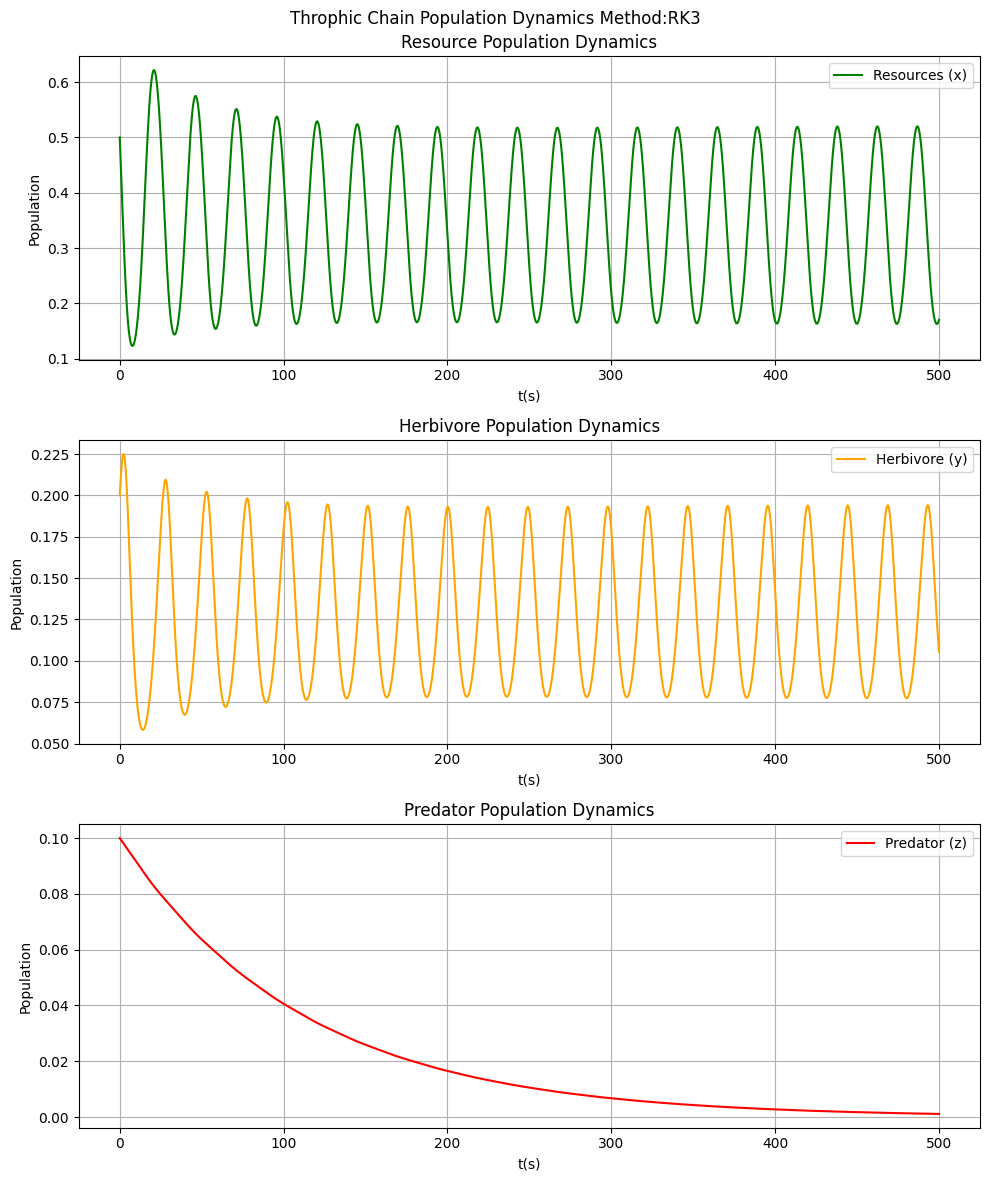

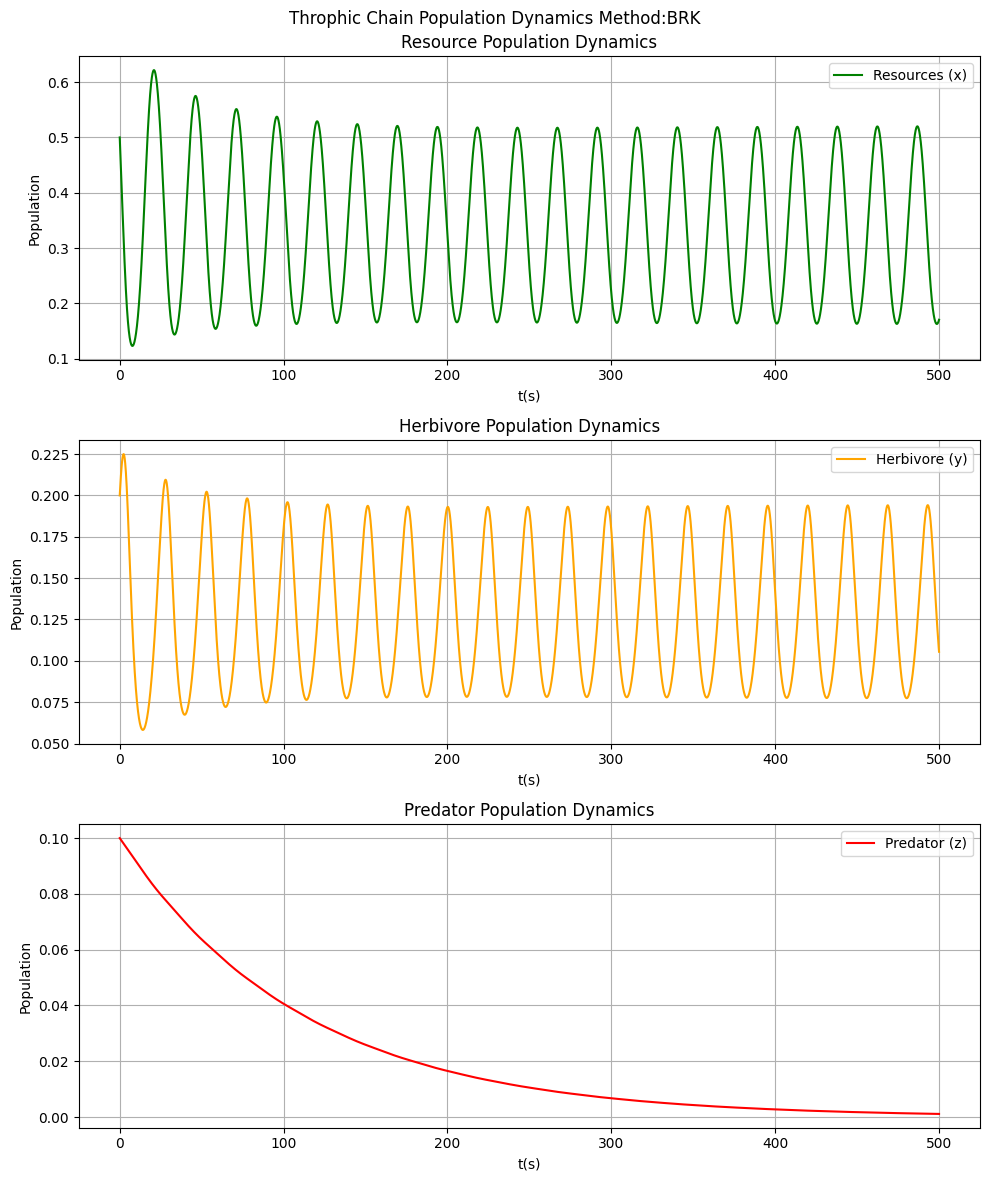

In [21]:
# Loop to integrate the ODE with both methods
for method in settings['method']:     
    # Crate an instance of the class
    instance_both = ChainDinamics(
        parameters=settings['parameters'], 
        init_c=settings['init_c'], 
        t_span=settings['t_span'], 
        step_size=settings['step_size'], 
        method=method)
    # Call the class method to integrate the ODE
    t , S = instance_both.integrate_ODE()
    # Compare the results of both methods
    instance_both.final_plot(t, S)

When we ran the simulation using the initial parameters for both the RK3 and BRK methods, we obtained identical plots, suggesting that both methods are highly robust in generating a reliable solution.
There may be a slight variation in the decimal places of the state vector, which is due to the order of approximation used to define the BRK method, which is sixth order. 

**(j)** Based on your results:

- Does the top predator ($z$) survive? If not, suggest 1 or 2 parameter changes that could allow the predator to persist in the system. 

With the previous parameters and within the established time interval, you can see how the top predator comes close to the x-axis, meaning that the top predator almost disappears completely. To determine which parameters we must change so that the top predator population does not disappear, we must analyze the dynamics of the predator given by the equation dz/dt. 

$$
\begin{aligned}
\frac{dz}{dt} &= \frac{e_2\,a_2\,y\,z}{1 + b_2\,y} - d_2\,z
\end{aligned}
$$

For the population to grow, dz/dt > 0; we will analyze the stability of the fixed point, that is, when dz/dt = 0.

$$ 0= z( {\frac{e_2 a_2 y}{1 + b_2 y}} - {d_2})$$

1. Trivial solution
$$ z = 0 $$

2. Threshold of survival
$$ \frac{e_2 a_2 y}{1 + b_2 y} - d_2 = 0 $$

Solving the second equation gives us the number of herbivores. This value is very important because it determines the predator’s survival, which in turn causes its population to grow or disappear.

$$ y = \frac{d_2}{e_2 a_2 - d_2 b_2} $$

When evaluating the model using the initial parameters, we find that the herbivore population value y = -1. As a result, the predator population is doomed to extinction with these parameters. Therefore, we must adjust the parameter values so that y > 0. This means that e2*a2 > d2*b2.


To determine a value, I ran some tests by adjusting the values of certain parameters: e2 (energy conversion efficiency), d2 (mortality rate), and a1 (predator capture rate). By adjusting these values to an optimal level, I obtained the same result. I found that when e2 = 1 or d2 = 0.001 or a1 = 1, the predator population increases, while the herbivore populations and resources decrease throughout the simulation. For this graph, I set e2 = 1 and kept the other parameters at their initial values.

In [22]:
# Create a diccionary with the parameters
settings_prob = {
            'parameters': {
                        'r': 0.5, 
                        'k': 1.0, 
                        'a1': 5.0, 
                        'b1': 3.0, 
                        'e1': 0.5, 
                        'd1': 0.4, 
                        'a2': 0.1, 
                        'b2': 2.0, 
                        'e2': 1.0, 
                        'd2': 0.01},
            'init_c': [0.5, 0.2, 0.1],
            't_span': (0, 500),
            'step_size': 0.05,
            'method': ["RK3", "BRK"]
        }

In [23]:
# First, we select the method to integrate the ODE
selected_method = settings_prob['method'][0]
#print(f"The selected method is: {selected_method}")   
# Create an instance of the class 
instance_prob = ChainDinamics(
    parameters=settings_prob['parameters'], 
    init_c=settings_prob['init_c'], 
    t_span=settings_prob['t_span'], 
    step_size=settings_prob['step_size'], 
    method=selected_method)

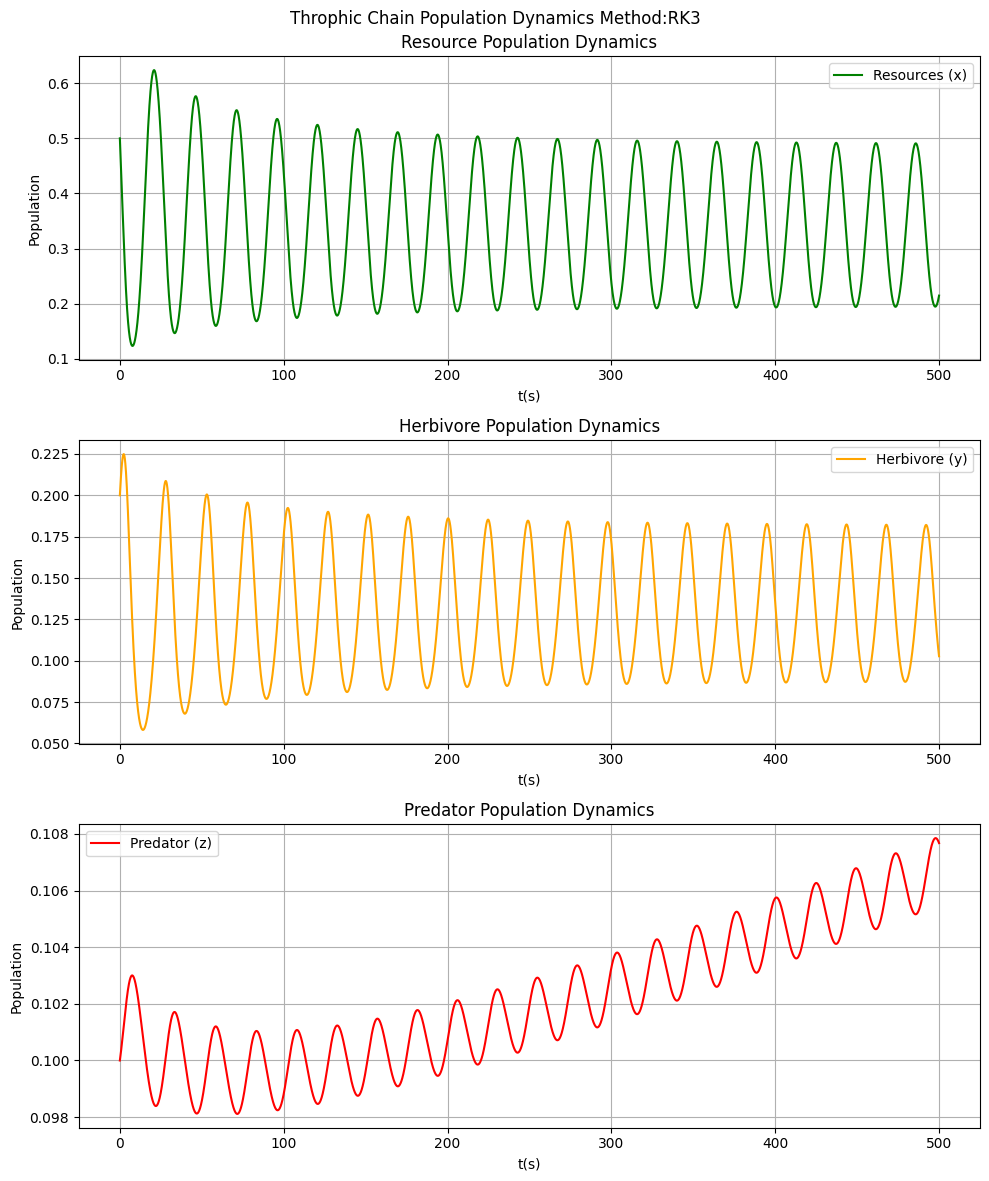

In [24]:
t , S_prob = instance_prob.integrate_ODE()
instance_prob.final_plot(t, S_prob)

- Briefly justify your answer based on the ecological meaning of the parameter/s.

The adjustable parameters for the predator represent efficiency, success, and mortality. With these initial parameters, we obtained a negative y-value, which implies the predator's extinction. Modifying a parameter can guarantee the survival of one species but can also lead to the extinction of another. Therefore, adjusting the parameters has an impact where the goal is predator efficiency, but not so high as to guarantee the dominance of other species.